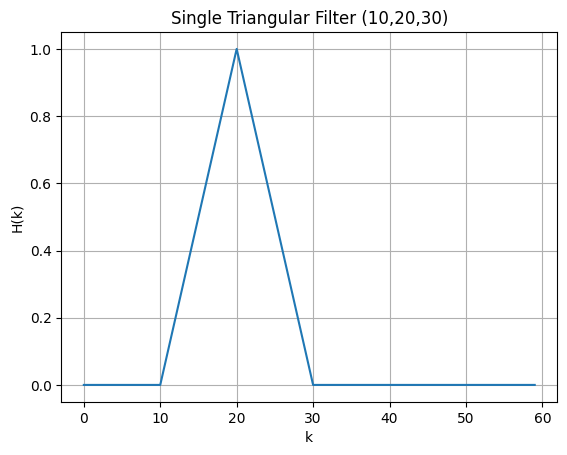

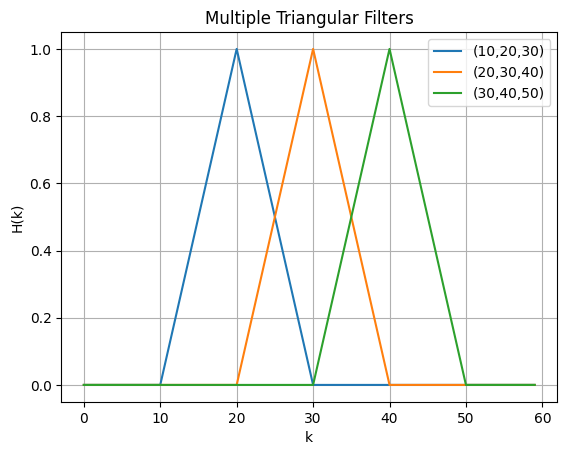

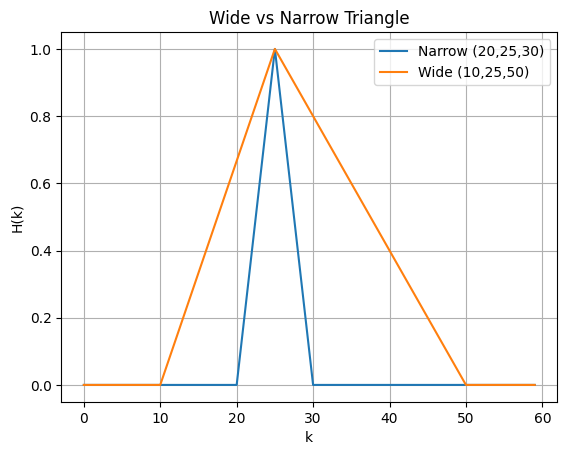

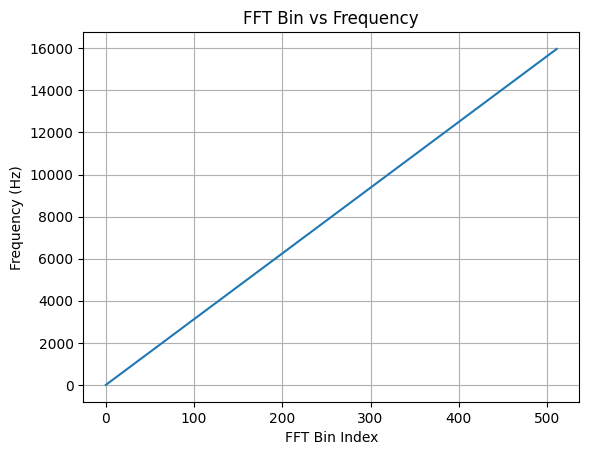

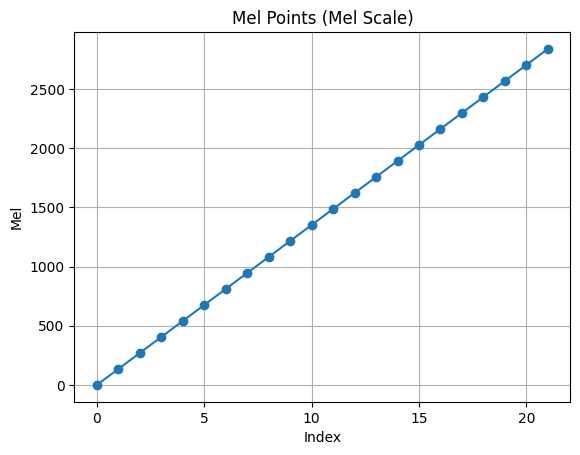

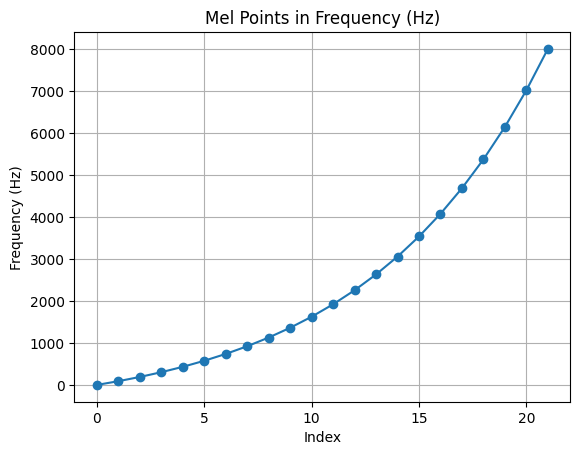

Triangular Filter Points (a,b,c):

Filter 1: a=0, b=2, c=6
Filter 2: a=2, b=6, c=9
Filter 3: a=6, b=9, c=13
Filter 4: a=9, b=13, c=18
Filter 5: a=13, b=18, c=23
Filter 6: a=18, b=23, c=29
Filter 7: a=23, b=29, c=36
Filter 8: a=29, b=36, c=43
Filter 9: a=36, b=43, c=52
Filter 10: a=43, b=52, c=61
Filter 11: a=52, b=61, c=72
Filter 12: a=61, b=72, c=84
Filter 13: a=72, b=84, c=97
Filter 14: a=84, b=97, c=113
Filter 15: a=97, b=113, c=130
Filter 16: a=113, b=130, c=150
Filter 17: a=130, b=150, c=172
Filter 18: a=150, b=172, c=196
Filter 19: a=172, b=196, c=224
Filter 20: a=196, b=224, c=256


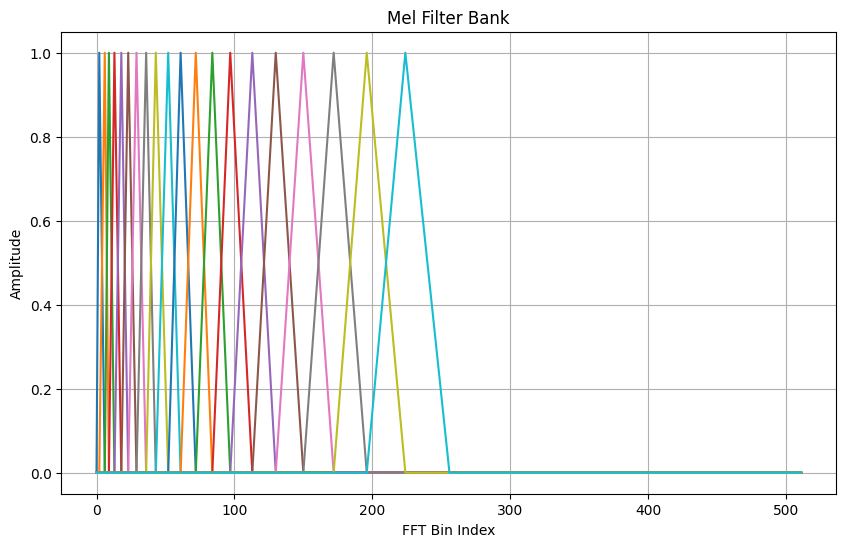

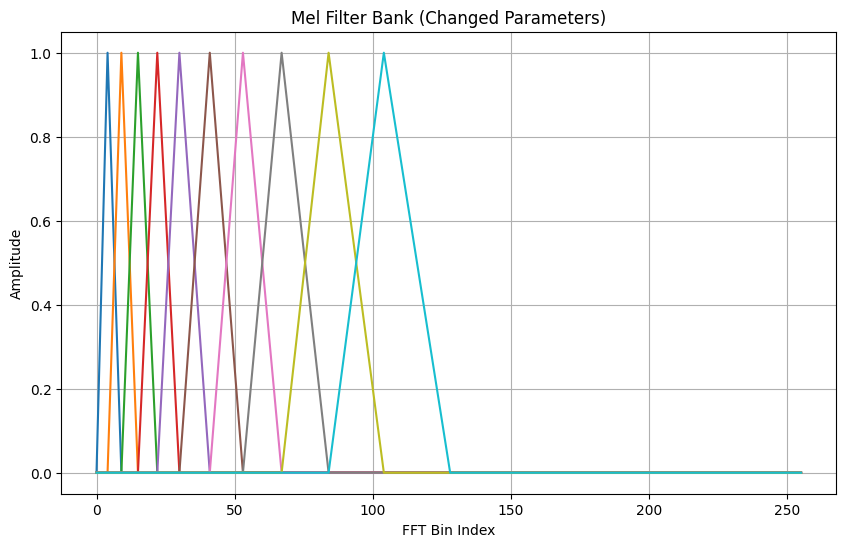

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# OBJECTIVE 1: TRIANGULAR FILTERS


def triangular_filter(k, a, b, c):

    H = np.zeros_like(k, dtype=float)

    # Rising edge
    idx = np.logical_and(k >= a, k <= b)
    H[idx] = (k[idx] - a) / (b - a)

    # Falling edge (strictly greater than b)
    idx = np.logical_and(k > b, k <= c)
    H[idx] = (c - k[idx]) / (c - b)

    return H


# (i) Single triangular filter
k = np.arange(0, 60)

H1 = triangular_filter(k, 10, 20, 30)

plt.figure()
plt.plot(k, H1)
plt.title("Single Triangular Filter (10,20,30)")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.grid()
plt.show()


# (ii) Multiple triangular filters

triangles = [(10,20,30),(20,30,40),(30,40,50)]

plt.figure()

for (a,b,c) in triangles:
    H = triangular_filter(k,a,b,c)
    plt.plot(k,H,label=f"({a},{b},{c})")

plt.title("Multiple Triangular Filters")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()


# (iii) Wide vs Narrow triangle

plt.figure()

H_narrow = triangular_filter(k,20,25,30)
H_wide = triangular_filter(k,10,25,50)

plt.plot(k,H_narrow,label="Narrow (20,25,30)")
plt.plot(k,H_wide,label="Wide (10,25,50)")

plt.title("Wide vs Narrow Triangle")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()




# OBJECTIVE 2: MEL FILTER BANK


# Step 1: Parameters

fs = 16000
N = 512
M = 20

f_min = 0
f_max = fs/2


# Step 2: Hz ↔ Mel conversion

def hz_to_mel(f):

    return 2595 * np.log10(1 + f/700)


def mel_to_hz(m):

    return 700 * (10**(m/2595) - 1)


mel_min = hz_to_mel(f_min)
mel_max = hz_to_mel(f_max)


# Step 3: Generate equally spaced Mel points

mel_points = np.linspace(mel_min,mel_max,M+2)


# Step 4: Convert Mel back to frequency

f_points = mel_to_hz(mel_points)


# Step 5: Convert frequency to FFT bins

bins = np.floor((N+1) * f_points / fs).astype(int)




# PLOT 1: FFT Bin vs Frequency


k = np.arange(0,N)
freqs = k * fs / N

plt.figure()
plt.plot(k,freqs)
plt.title("FFT Bin vs Frequency")
plt.xlabel("FFT Bin Index")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()




# PLOT 2: Mel Points


plt.figure()
plt.plot(mel_points,'o-')
plt.title("Mel Points (Mel Scale)")
plt.xlabel("Index")
plt.ylabel("Mel")
plt.grid()
plt.show()




# PLOT 3: Mel Points in Frequency (Hz)


plt.figure()
plt.plot(f_points,'o-')
plt.title("Mel Points in Frequency (Hz)")
plt.xlabel("Index")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()




# PRINT TRIANGULAR FILTER POINTS


print("Triangular Filter Points (a,b,c):\n")

filter_points = []

for m in range(1,M+1):

    a = bins[m-1]
    b = bins[m]
    c = bins[m+1]

    filter_points.append((a,b,c))

    print(f"Filter {m}: a={a}, b={b}, c={c}")




# CONSTRUCT MEL FILTER BANK


filter_bank = np.zeros((M,N))


for m in range(1,M+1):

    a = bins[m-1]
    b = bins[m]
    c = bins[m+1]

    for k in range(a,b):

        filter_bank[m-1,k] = (k-a)/(b-a)

    for k in range(b,c):

        filter_bank[m-1,k] = (c-k)/(c-b)




# PLOT MEL FILTER BANK


plt.figure(figsize=(10,6))

for m in range(M):

    plt.plot(filter_bank[m])

plt.title("Mel Filter Bank")
plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()




# PARAMETER CHANGE VISUALIZATION


fs2 = 8000
N2 = 256
M2 = 10

f_max2 = fs2/2

mel_min2 = hz_to_mel(0)
mel_max2 = hz_to_mel(f_max2)

mel_points2 = np.linspace(mel_min2,mel_max2,M2+2)

f_points2 = mel_to_hz(mel_points2)

bins2 = np.floor((N2+1) * f_points2 / fs2).astype(int)


filter_bank2 = np.zeros((M2,N2))


for m in range(1,M2+1):

    a = bins2[m-1]
    b = bins2[m]
    c = bins2[m+1]

    for k in range(a,b):

        filter_bank2[m-1,k] = (k-a)/(b-a)

    for k in range(b,c):

        filter_bank2[m-1,k] = (c-k)/(c-b)



plt.figure(figsize=(10,6))

for m in range(M2):

    plt.plot(filter_bank2[m])

plt.title("Mel Filter Bank (Changed Parameters)")
plt.xlabel("FFT Bin Index")
plt.ylabel("Amplitude")
plt.grid()
plt.show()